# Notebook 2: Classification Modelling & Hyperparameter Tuning

**Module:** Machine Learning Coursework  
**Purpose:** Build, evaluate, and tune classification models (Logistic Regression, K-Nearest Neighbours, and Gaussian Naïve Bayes) on the preprocessed loan approval dataset. Models are compared by multiple metrics and the best model (by recall) is selected for hyperparameter tuning using GridSearchCV.

---

## 1. Load Preprocessed Data

We use `%run` to execute Notebook 1 directly, making all its output variables (`X_classification_scaled`, `y_classification`, etc.) available in this kernel's namespace without copying or re-processing the data.

All libraries imported successfully.
Dataset loaded successfully.
Dataset shape: 58645 rows x 13 columns
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-n

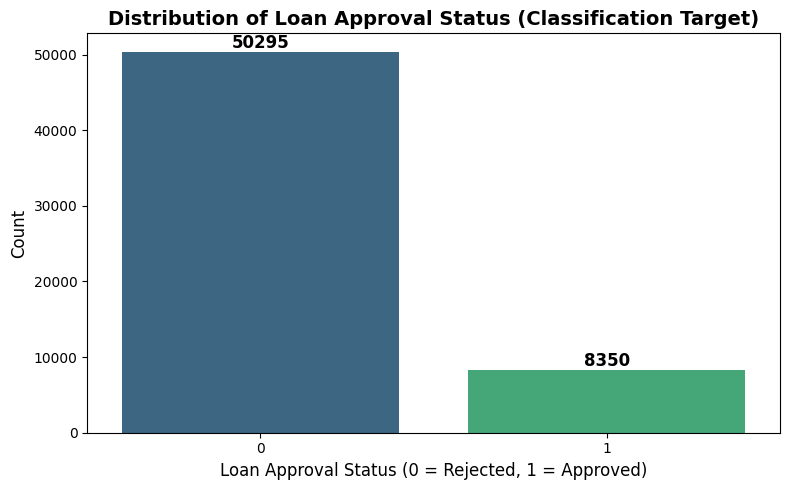


Class Distribution (percentage):
loan_approval_status
0    85.76
1    14.24
Name: proportion, dtype: float64


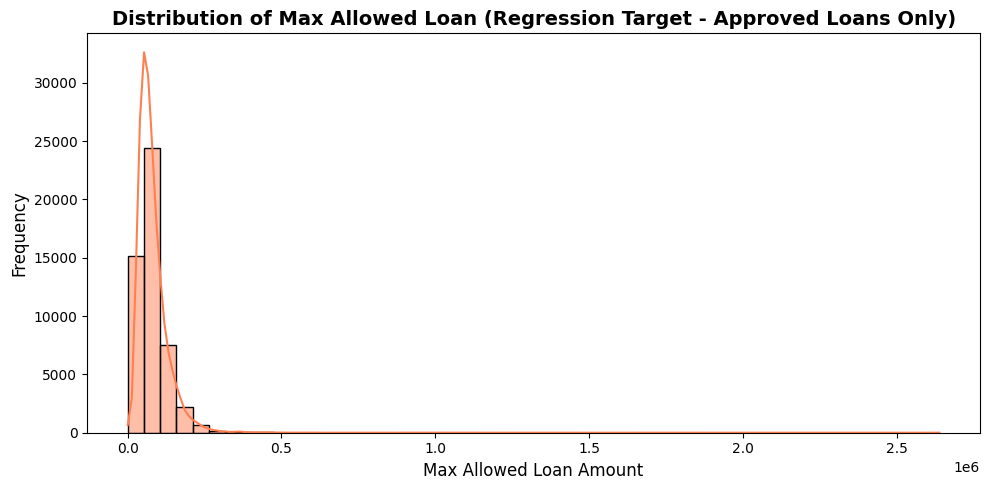


Regression Target Statistics (non-zero max_allowed_loan):
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
Preprocessing complete. Variables loaded:
  X_classification_scaled : (58645, 10)
  y_classification        : (58645,)


In [1]:
# Execute Notebook 1 to load and preprocess the loan dataset
%run loan_data_preprocessing.ipynb

# Confirm the key variables are available in the current namespace
print("Preprocessing complete. Variables loaded:")

# Print the shape of the scaled classification feature matrix
print(f"  X_classification_scaled : {X_classification_scaled.shape}")

# Print the shape of the classification target vector
print(f"  y_classification        : {y_classification.shape}")

---
## 2. Import Libraries

All libraries required for classification modelling, evaluation and hyperparameter tuning are imported here:
- **scikit-learn** for models, metrics, and GridSearchCV
- **matplotlib** and **seaborn** for plotting
- **pandas** and **numpy** for data handling
- **warnings** to suppress non-critical messages

In [2]:
# Import numpy for numerical operations
import numpy as np

# Import pandas for DataFrame handling
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical visualisations
import seaborn as sns

# Import train_test_split for splitting data into training and test sets
from sklearn.model_selection import train_test_split

# Import GridSearchCV for exhaustive hyperparameter search
from sklearn.model_selection import GridSearchCV

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import confusion_matrix to evaluate prediction errors
from sklearn.metrics import confusion_matrix

# Import classification_report for per-class precision, recall, F1, support
from sklearn.metrics import classification_report

# Import individual classification performance metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Import roc_auc_score for computing AUC of the ROC curve
from sklearn.metrics import roc_auc_score

# Import roc_curve to compute the ROC curve coordinates
from sklearn.metrics import roc_curve

# Import warnings module to suppress non-critical output
import warnings

# Suppress all warnings to keep notebook output clean
warnings.filterwarnings('ignore')

# Confirm all libraries imported successfully
print("All libraries imported successfully.")

All libraries imported successfully.


### 2.1 Verify Classification Features and Target

Before splitting or training, confirm the feature names, data shapes, and target class distribution loaded from Notebook 1.

In [3]:
# ── Feature Names ────────────────────────────────────────────────────────────

# Print the list of all feature column names used for classification
print("Feature Names Used for Classification:")

# Retrieve column names from the scaled feature DataFrame
print(X_classification_scaled.columns.tolist())

# ── Data Shapes ──────────────────────────────────────────────────────────────

# Print the shape of the full feature matrix (rows, columns)
print(f"\nFeatures Shape (X): {X_classification_scaled.shape}")

# Print the shape of the full target vector
print(f"Target Shape (y): {y_classification.shape}")

# ── Target Distribution ──────────────────────────────────────────────────────

# Print the class counts for the classification target variable
print("\nTarget Distribution:")

# Display value counts showing how many samples belong to each class
print(y_classification.value_counts())


Feature Names Used for Classification:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Features Shape (X): (58645, 10)
Target Shape (y): (58645,)

Target Distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


---
## 3. Train-Test Split

The preprocessed dataset is split into training and test sets using an 80/20 ratio.

- **`test_size=0.2`** — 20% of samples are held out for evaluation
- **`stratify=y`** — preserves the class distribution in both splits, important because the dataset is imbalanced (~14% positives)
- **`random_state=42`** — ensures reproducibility

In [4]:
# Split the scaled feature matrix and target vector into training and test sets
# test_size=0.2 reserves 20% of the data for evaluation
# stratify=y_classification ensures class proportions are preserved in both splits
# random_state=42 guarantees reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X_classification_scaled,
    y_classification,
    test_size=0.2,
    stratify=y_classification,
    random_state=42
)

# Print the resulting sizes of each split
print(f"Training set size  : {X_train.shape[0]} samples")

# Print test set size
print(f"Test set size      : {X_test.shape[0]} samples")

# Print feature count
print(f"Number of features : {X_train.shape[1]}")

# Print class distribution in the training set
print(f"\nClass distribution in training set:")

# Count positive and negative samples in training target
print(y_train.value_counts())

# Print class distribution in the test set
print(f"\nClass distribution in test set:")

# Count positive and negative samples in test target
print(y_test.value_counts())

Training set size  : 46916 samples
Test set size      : 11729 samples
Number of features : 10

Class distribution in training set:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

Class distribution in test set:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


### 3.1 Training and Test Set Summary

Confirm the shapes of the training and test sets, and verify that the **class proportions** are preserved after stratified splitting.

In [5]:
# Display the shapes of the training and test sets
print(f'Training set shape: X_train={X_train.shape}, y_train={y_train.shape}')
print(f'Test set shape: X_test={X_test.shape}, y_test={y_test.shape}')

# Verify the stratified split preserves class ratios
print(f'\nTraining set class distribution:\n{y_train.value_counts(normalize=True)}')
print(f'\nTest set class distribution:\n{y_test.value_counts(normalize=True)}')


Training set shape: X_train=(46916, 10), y_train=(46916,)
Test set shape: X_test=(11729, 10), y_test=(11729,)

Training set class distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

Test set class distribution:
loan_approval_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


---
## 4. Build & Train Classification Models

Three classifiers are instantiated and trained on the training data:

1. **Logistic Regression** — a linear baseline classifier; `max_iter=1000` ensures convergence on this dataset
2. **K-Nearest Neighbours (KNN)** — a non-parametric instance-based learner using the 5 nearest neighbours by default
3. **Gaussian Naïve Bayes** — a probabilistic classifier that assumes feature independence and Gaussian distributions

All models are trained using the same `X_train` / `y_train` split for fair comparison.

In [6]:
# ── Logistic Regression ────────────────────────────────────────────────────

# Instantiate Logistic Regression with a higher max_iter to ensure convergence
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the Logistic Regression model on the training data
lr_model.fit(X_train, y_train)

# Confirm training is complete
print("Logistic Regression trained successfully.")

# ── K-Nearest Neighbours ───────────────────────────────────────────────────

# Instantiate KNN with default 5 neighbours
knn_model = KNeighborsClassifier()

# Train the KNN model on the training data
knn_model.fit(X_train, y_train)

# Confirm training is complete
print("K-Nearest Neighbours trained successfully.")

# ── Gaussian Naive Bayes ───────────────────────────────────────────────────

# Instantiate Gaussian Naive Bayes (no hyperparameters required at this stage)
gnb_model = GaussianNB()

# Train the Gaussian NB model on the training data
gnb_model.fit(X_train, y_train)

# Confirm training is complete
print("Gaussian Naive Bayes trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbours trained successfully.
Gaussian Naive Bayes trained successfully.


---
## 5. Evaluate Each Model

Each model is evaluated using the following metrics:
- **Confusion Matrix** — shows true/false positives and negatives
- **Classification Report** — per-class precision, recall, F1-score, and support
- **Accuracy** — proportion of correct predictions overall
- **Recall** — proportion of actual positives correctly identified (key metric for loan approval)
- **Precision** — proportion of positive predictions that are correct (`zero_division=0` prevents divide-by-zero errors)
- **F1-Score** — harmonic mean of precision and recall
- **AUC-ROC** — area under the ROC curve, measuring overall discriminatory power

> **Note:** `zero_division=0` is used in precision/recall calculations to handle edge cases where a class has no predicted samples.

In [7]:
# Define a reusable function to evaluate any trained classifier
def evaluate_model(model, X_test, y_test, model_name, cmap='Blues'):
    """
    Evaluates a trained classifier and prints all required metrics.

    Parameters
    ----------
    model      : trained scikit-learn classifier
    X_test     : test feature matrix
    y_test     : true test labels
    model_name : string label for display purposes
    cmap       : matplotlib colormap name for the confusion matrix heatmap

    Returns
    -------
    dict of metric name -> value
    """
    # Generate class predictions using the trained model
    y_pred = model.predict(X_test)

    # Generate probability estimates for the positive class (used for AUC)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Print a clearly formatted section header for the current model
    print("=" * 60)
    print(f"  MODEL: {model_name}")
    print("=" * 60)

    # ── Confusion Matrix ──────────────────────────────────────

    # Print the confusion matrix header
    print("\n[Confusion Matrix]")

    # Compute the confusion matrix from true and predicted labels
    cm = confusion_matrix(y_test, y_pred)

    # Display the confusion matrix as a seaborn heatmap for readability
    plt.figure(figsize=(5, 4))

    # Draw the annotated heatmap with class labels
    # Each model uses a unique colormap for visual distinction
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=['Approved', 'Rejected'],
        yticklabels=['Approved', 'Rejected']
    )

    # Set the title of the confusion matrix plot
    plt.title(f'{model_name} - Test Confusion Matrix', fontsize=12, fontweight='bold')

    # Label the x-axis
    plt.xlabel('Predicted label', fontsize=10)

    # Label the y-axis
    plt.ylabel('True label', fontsize=10)

    # Apply tight layout to prevent text overlap
    plt.tight_layout()

    # Display the confusion matrix heatmap
    plt.show()

    # ── Classification Report ─────────────────────────────────

    # Print the classification report header
    print("\n[Classification Report]")

    # Display precision, recall, F1, and support for each class
    # zero_division=0 prevents division-by-zero warnings on empty predictions
    print(classification_report(y_test, y_pred, zero_division=0))

    # ── Individual Metrics ────────────────────────────────────

    # Compute overall accuracy (proportion of correct predictions)
    acc = accuracy_score(y_test, y_pred)

    # Compute recall for the positive class; zero_division=0 for safety
    rec = recall_score(y_test, y_pred, zero_division=0)

    # Compute precision for the positive class; zero_division=0 for safety
    prec = precision_score(y_test, y_pred, zero_division=0)

    # Compute F1-score for the positive class
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Compute AUC-ROC using predicted probabilities
    auc = roc_auc_score(y_test, y_proba)

    # Print each metric in the required format
    print(f"Accuracy  : {acc:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # Print AUC in the exact required format
    print(f"AUC-ROC: {auc:.4f}")

    # Return all metrics as a dictionary for later comparison
    return {
        'Model'    : model_name,
        'Accuracy' : acc,
        'Recall'   : rec,
        'Precision': prec,
        'F1-Score' : f1,
        'AUC-ROC'  : auc,
        'y_proba'  : y_proba
    }

### 5.1 Logistic Regression Evaluation

  MODEL: Logistic Regression

[Confusion Matrix]


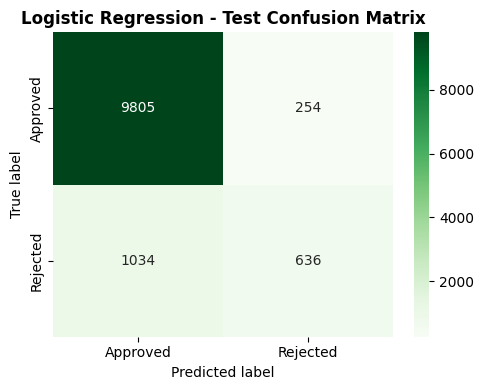


[Classification Report]
              precision    recall  f1-score   support

           0       0.90      0.97      0.94     10059
           1       0.71      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

Accuracy  : 0.8902
Recall    : 0.3808
Precision : 0.7146
F1-Score  : 0.4969
AUC-ROC: 0.8714


In [8]:
# Evaluate the trained Logistic Regression model on the held-out test set
lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression", cmap='Greens')

### 5.2 K-Nearest Neighbours Evaluation

  MODEL: K-Nearest Neighbours

[Confusion Matrix]


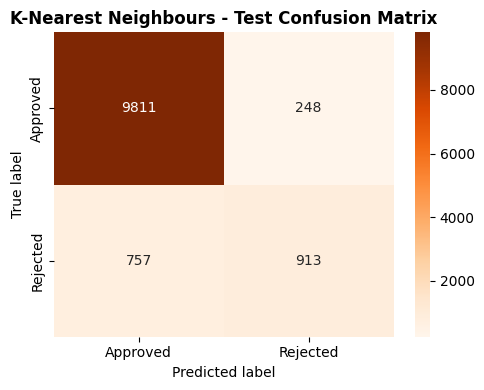


[Classification Report]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.79      0.55      0.65      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.76      0.80     11729
weighted avg       0.91      0.91      0.91     11729

Accuracy  : 0.9143
Recall    : 0.5467
Precision : 0.7864
F1-Score  : 0.6450
AUC-ROC: 0.8553


In [9]:
# Evaluate the trained KNN model on the held-out test set
knn_results = evaluate_model(knn_model, X_test, y_test, "K-Nearest Neighbours", cmap='Oranges')

### 5.3 Gaussian Naïve Bayes Evaluation

  MODEL: Gaussian Naive Bayes

[Confusion Matrix]


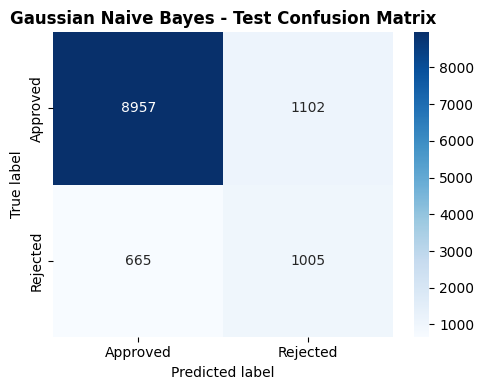


[Classification Report]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10059
           1       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729

Accuracy  : 0.8493
Recall    : 0.6018
Precision : 0.4770
F1-Score  : 0.5322
AUC-ROC: 0.8548


In [10]:
# Evaluate the trained Gaussian Naive Bayes model on the held-out test set
gnb_results = evaluate_model(gnb_model, X_test, y_test, "Gaussian Naive Bayes", cmap='Blues')

---
## 6. ROC Curves for All Models

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (Recall) against the False Positive Rate at various classification thresholds. A higher AUC indicates better discriminatory ability.

All three models are plotted on the same axes for direct visual comparison. The diagonal dashed line represents a random classifier (AUC = 0.5).

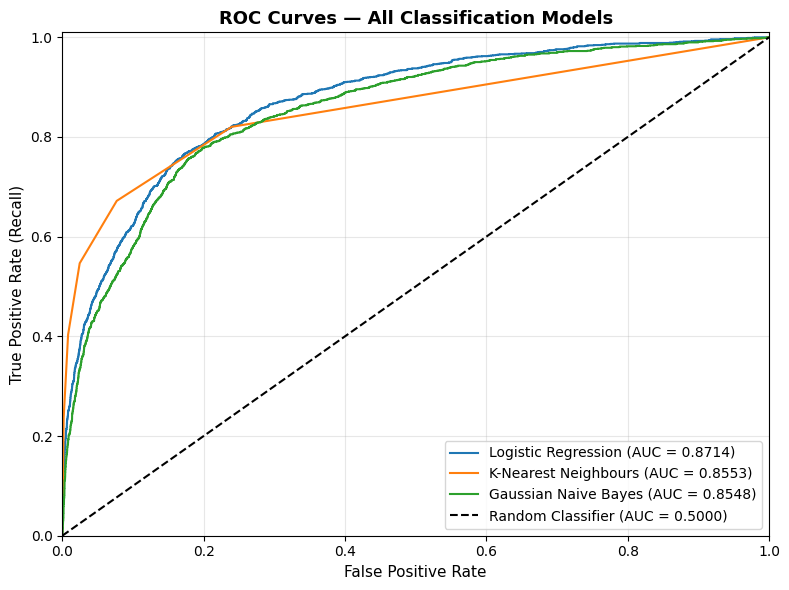

AUC-ROC Summary:
  Logistic Regression            AUC = 0.8714
  K-Nearest Neighbours           AUC = 0.8553
  Gaussian Naive Bayes           AUC = 0.8548


In [11]:
# Create a figure for the combined ROC curve plot
plt.figure(figsize=(8, 6))

# Iterate over each model's results to plot its ROC curve
for results in [lr_results, knn_results, gnb_results]:
    # Extract the model's predicted probabilities for the positive class
    y_proba = results['y_proba']

    # Compute the false positive rate, true positive rate, and thresholds
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # Plot the ROC curve for this model, labelling it with name and AUC score
    plt.plot(fpr, tpr, label=f"{results['Model']} (AUC = {results['AUC-ROC']:.4f})")

# Draw the diagonal dashed line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

# Set the title of the ROC plot
plt.title('ROC Curves — All Classification Models', fontsize=13, fontweight='bold')

# Label the x-axis
plt.xlabel('False Positive Rate', fontsize=11)

# Label the y-axis
plt.ylabel('True Positive Rate (Recall)', fontsize=11)

# Add a legend to identify each model's curve
plt.legend(loc='lower right', fontsize=10)

# Set axis limits so the full ROC space [0,1] x [0,1] is visible
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])

# Add a light grid for easier reading
plt.grid(alpha=0.3)

# Apply tight layout to prevent label clipping
plt.tight_layout()

# Display the ROC curve plot
plt.show()

# Print AUC values for quick reference
print("AUC-ROC Summary:")
for results in [lr_results, knn_results, gnb_results]:
    # Print model name with its AUC score
    print(f"  {results['Model']:<30} AUC = {results['AUC-ROC']:.4f}")

---
## 7. Model Comparison Table

All five metrics are collated into a single comparison DataFrame, sorted by **Recall** in descending order so the best-performing model appears at the top.

> **Recall** is our primary selection criterion because in a loan approval context, missing a genuine approval (false negative) is typically more costly than a false alarm.

In [12]:
# Collect all metrics results (excluding the y_proba array) into a list of dicts
comparison_data = []

# Compile metrics from each model's results dictionary
for results in [lr_results, knn_results, gnb_results]:
    # Build a row dict without the raw probability array
    row = {k: v for k, v in results.items() if k != 'y_proba'}

    # Append this model's metrics row to the list
    comparison_data.append(row)

# Create a pandas DataFrame from the collected metrics
comparison_df = pd.DataFrame(comparison_data)

# Set the Model column as the index for cleaner display
comparison_df = comparison_df.set_index('Model')

# Sort all models by Recall (primary evaluation metric) in descending order
comparison_df = comparison_df.sort_values('Recall', ascending=False)

# Round all numeric values to 4 decimal places for consistent display
comparison_df = comparison_df.round(4)

# Print a clear section header
print("=" * 60)
print("  MODEL COMPARISON TABLE (sorted by Recall)")
print("=" * 60)

# Display the full comparison DataFrame
print(comparison_df.to_string())

# Print a separator line for readability
print("=" * 60)

  MODEL COMPARISON TABLE (sorted by Recall)
                      Accuracy  Recall  Precision  F1-Score  AUC-ROC
Model                                                               
Gaussian Naive Bayes    0.8493  0.6018     0.4770    0.5322   0.8548
K-Nearest Neighbours    0.9143  0.5467     0.7864    0.6450   0.8553
Logistic Regression     0.8902  0.3808     0.7146    0.4969   0.8714


---
## 8. Select Best Model Based on Recall

The model with the **highest Recall** on the test set is selected as the best baseline model. Recall measures how many of the actual loan approvals our model correctly identifies — minimising false negatives is critical to avoid rejecting genuinely creditworthy applicants.

In [13]:
# Identify the model name with the highest Recall score
best_model_name = comparison_df['Recall'].idxmax()

# Retrieve the full results dict for the best model
best_results_map = {
    'Logistic Regression'   : lr_results,
    'K-Nearest Neighbours'  : knn_results,
    'Gaussian Naive Bayes'  : gnb_results
}

# Retrieve the best raw model object for hyperparameter tuning
best_model_obj_map = {
    'Logistic Regression'   : lr_model,
    'K-Nearest Neighbours'  : knn_model,
    'Gaussian Naive Bayes'  : gnb_model
}

# Store the best model's results for comparison later
best_baseline_results = best_results_map[best_model_name]

# Store the best trained model object
best_model_obj = best_model_obj_map[best_model_name]

# Print the winning model and its key metrics
print("=" * 60)
print(f"  BEST MODEL (by Recall): {best_model_name}")
print("=" * 60)

# Print Recall of the selected best model
print(f"  Recall    : {best_baseline_results['Recall']:.4f}")

# Print Accuracy of the selected best model
print(f"  Accuracy  : {best_baseline_results['Accuracy']:.4f}")

# Print Precision of the selected best model
print(f"  Precision : {best_baseline_results['Precision']:.4f}")

# Print F1-Score of the selected best model
print(f"  F1-Score  : {best_baseline_results['F1-Score']:.4f}")

# Print AUC of the selected best model
print(f"  AUC-ROC: {best_baseline_results['AUC-ROC']:.4f}")

# Print separator for clarity
print("=" * 60)

  BEST MODEL (by Recall): Gaussian Naive Bayes
  Recall    : 0.6018
  Accuracy  : 0.8493
  Precision : 0.4770
  F1-Score  : 0.5322
  AUC-ROC: 0.8548


---
## 9. Hyperparameter Tuning with GridSearchCV

The best model (determined by Recall in Section 8) is tuned using **GridSearchCV** with:
- **`scoring='recall'`** — optimises for maximising recall on the positive class
- **`cv=5`** — 5-fold stratified cross-validation for robust evaluation
- **`n_jobs=-1`** — uses all available CPU cores for faster search

A dedicated parameter grid is defined for each possible best model.

In [14]:
# === Hyperparameter Tuning for KNN (selected as best model) ===

# Define the hyperparameter grid for KNN
# Explores different values of K, distance weighting, and distance metrics
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create a GridSearchCV instance with 5-fold cross-validation
# Scoring set to 'recall' to prioritise detecting Rejected applications
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)

# Fit the GridSearchCV on the scaled training data
grid_search_knn.fit(X_train, y_train)

# Print the best hyperparameter combination found
print(f"Best parameters found : {grid_search_knn.best_params_}")

# Print the best cross-validated recall score from the search
print(f"Best CV Recall score  : {grid_search_knn.best_score_:.4f}")

Best parameters found : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Recall score  : 0.5509


---
## 10. Evaluate Tuned Model — Before vs After Comparison

The tuned model (using the best hyperparameters found by GridSearchCV) is evaluated on the held-out test set and directly compared against the baseline (default hyperparameters) to quantify the improvement.

  MODEL: K-Nearest Neighbours (Tuned)

[Confusion Matrix]


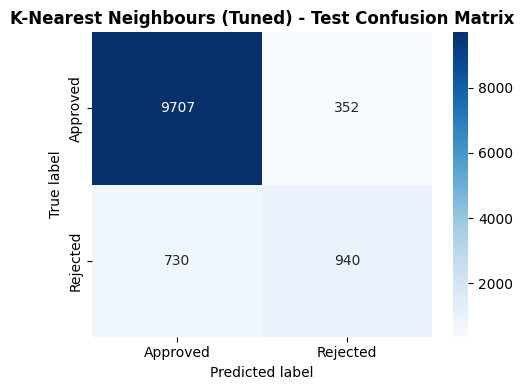


[Classification Report]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10059
           1       0.73      0.56      0.63      1670

    accuracy                           0.91     11729
   macro avg       0.83      0.76      0.79     11729
weighted avg       0.90      0.91      0.90     11729

Accuracy  : 0.9078
Recall    : 0.5629
Precision : 0.7276
F1-Score  : 0.6347
AUC-ROC: 0.8351


In [15]:
# Retrieve the best estimator found by GridSearchCV (already refitted on full training data)
tuned_model = grid_search_knn.best_estimator_

# Evaluate the tuned model on the test set using the same evaluate_model function
tuned_results = evaluate_model(
    tuned_model,
    X_test,
    y_test,
    "K-Nearest Neighbours (Tuned)"
)

### 10.1 Before vs After Comparison Table

In [16]:
# Build a comparison table between baseline and tuned model
# List the metrics to compare
metrics_to_compare = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'AUC-ROC']

# Create a comparison dictionary with baseline and tuned values
before_after = {
    'Metric'  : metrics_to_compare,
    'Baseline': [round(best_baseline_results[m], 4) for m in metrics_to_compare],
    'Tuned'   : [round(tuned_results[m], 4) for m in metrics_to_compare]
}

# Convert to a DataFrame for tabular display
before_after_df = pd.DataFrame(before_after)

# Compute the change (Tuned minus Baseline) for each metric
before_after_df['Change'] = (
    before_after_df['Tuned'] - before_after_df['Baseline']
).round(4)

# Add a direction indicator for readability
before_after_df['Direction'] = before_after_df['Change'].apply(
    lambda x: '▲ Improved' if x > 0 else ('▼ Declined' if x < 0 else '— No Change')
)

# Set Metric column as the index for clean display
before_after_df = before_after_df.set_index('Metric')

# Print a clear section header
print("=" * 65)
print(f"  BEFORE vs AFTER TUNING — {best_model_name}")
print("=" * 65)

# Display the full comparison table
print(before_after_df.to_string())

# Print a closing separator
print("=" * 65)

# Print the best hyperparameters for the tuned model
print(f"\nBest hyperparameters: {grid_search_knn.best_params_}")

  BEFORE vs AFTER TUNING — Gaussian Naive Bayes
           Baseline   Tuned  Change   Direction
Metric                                         
Accuracy     0.8493  0.9078  0.0585  ▲ Improved
Recall       0.6018  0.5629 -0.0389  ▼ Declined
Precision    0.4770  0.7276  0.2506  ▲ Improved
F1-Score     0.5322  0.6347  0.1025  ▲ Improved
AUC-ROC      0.8548  0.8351 -0.0197  ▼ Declined

Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


### 10.2 ROC Curve — Baseline vs Tuned

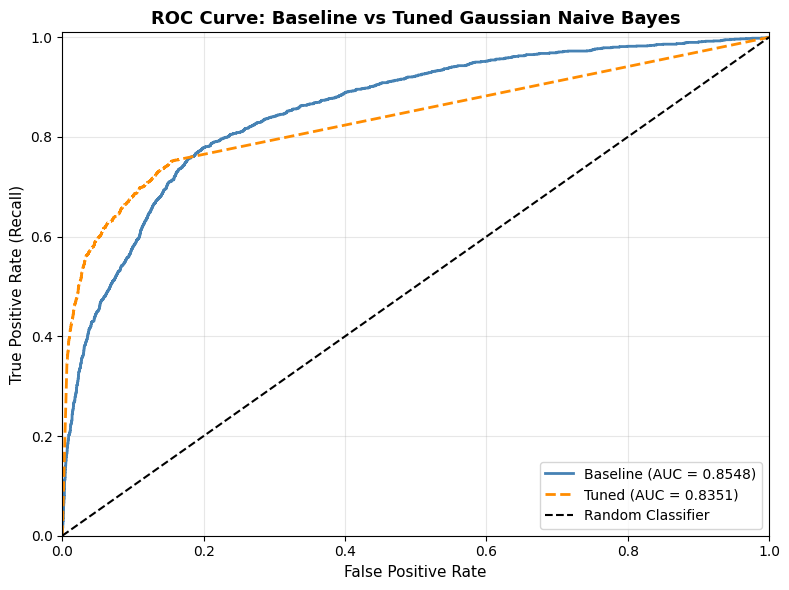

In [17]:
# Create a figure for the baseline vs tuned ROC comparison plot
plt.figure(figsize=(8, 6))

# ── Baseline model ROC ────────────────────────────────────────

# Compute ROC curve coordinates for the baseline model
fpr_base, tpr_base, _ = roc_curve(y_test, best_baseline_results['y_proba'])

# Plot the baseline ROC curve
plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline (AUC = {best_baseline_results['AUC-ROC']:.4f})",
    color='steelblue',
    linewidth=2
)

# ── Tuned model ROC ───────────────────────────────────────────

# Generate probability predictions from the tuned model
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

# Compute ROC curve coordinates for the tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

# Plot the tuned ROC curve
plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Tuned (AUC = {tuned_results['AUC-ROC']:.4f})",
    color='darkorange',
    linewidth=2,
    linestyle='--'
)

# ── Reference diagonal ────────────────────────────────────────

# Draw the diagonal dashed line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Set the title of the ROC comparison plot
plt.title(
    f'ROC Curve: Baseline vs Tuned {best_model_name}',
    fontsize=13,
    fontweight='bold'
)

# Label the x-axis
plt.xlabel('False Positive Rate', fontsize=11)

# Label the y-axis
plt.ylabel('True Positive Rate (Recall)', fontsize=11)

# Add a legend to identify the two model curves
plt.legend(loc='lower right', fontsize=10)

# Ensure the full ROC space is visible
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])

# Add a light grid for readability
plt.grid(alpha=0.3)

# Apply tight layout to prevent clipping
plt.tight_layout()

# Display the comparison ROC plot
plt.show()

---
## Summary

This notebook completed the following classification modelling pipeline:

| Step | Action |
|------|--------|
| 1 | Loaded preprocessed data from Notebook 1 via `%run` |
| 2 | Imported all required libraries |
| 3 | Split data: 80% training / 20% test, stratified by class, `random_state=42` |
| 4 | Built and trained 3 classifiers: Logistic Regression, KNN, Gaussian NB |
| 5 | Evaluated each model: Confusion Matrix, Classification Report, Accuracy, Recall, Precision, F1, AUC |
| 6 | Plotted ROC curves for all three models |
| 7 | Compared all models in a summary table sorted by Recall |
| 8 | Selected best model based on highest Recall |
| 9 | Performed hyperparameter tuning using GridSearchCV (`scoring='recall'`, `cv=5`) |
| 10 | Evaluated tuned model and produced a Before vs After comparison table and ROC plot |

### Models Used
- Logistic Regression
- K-Nearest Neighbours (KNN)
- Gaussian Naïve Bayes

---
*End of Notebook 2*